In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv('../data/data.csv', encoding='latin1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print(df.columns)
print(df.info())

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Fill missing Description values
df['Description'] = df['Description'].fillna('Unknown')

# Drop rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 5225


In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['Country'] = df['Country'].astype('category')

In [9]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [10]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Quantity'] >= lower) & (df['Quantity'] <= upper)]

In [11]:
df.to_csv('../data/cleaned_data.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 367076 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    367076 non-null  object        
 1   StockCode    367076 non-null  object        
 2   Description  367076 non-null  object        
 3   Quantity     367076 non-null  int64         
 4   InvoiceDate  367076 non-null  datetime64[ns]
 5   UnitPrice    367076 non-null  float64       
 6   CustomerID   367076 non-null  int64         
 7   Country      367076 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 22.8+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,367076.000000,367076,367076.000000,367076.000000
mean,7.094719,2011-07-11 02:45:25.328814592,3.240009,15302.780408
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000
25%,2.000000,2011-04-07 11:30:00,1.250000,13975.000000
50%,4.000000,2011-07-31 15:00:00,1.950000,15182.000000
75%,12.000000,2011-10-20 15:57:00,3.750000,16807.000000
max,27.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,6.670837,NaN,22.972315,1712.040348


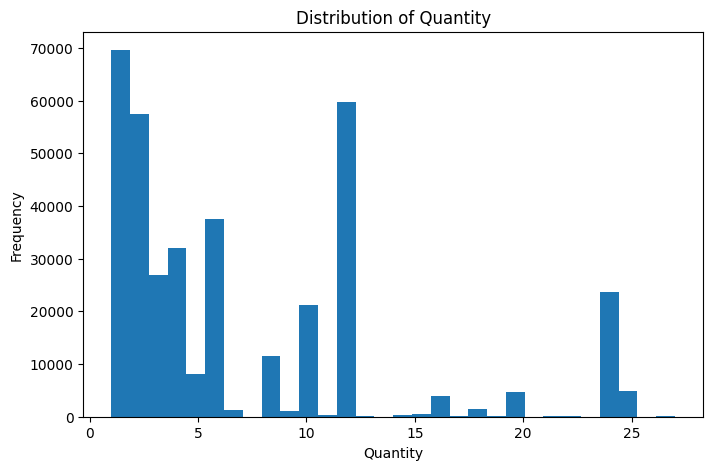

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=30)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()